# EDA : prédiction du churn client (Telco)

**Objectif** : comprendre les facteurs liés au départ des clients et décider des variables à conserver pour la modélisation.

**Données** : Telco Customer Churn (IBM, version Cognos), 7 043 clients, 33 colonnes.

**Plan**
1. Chargement
2. Qualité des données
3. Variable cible
4. Variables numériques
5. Variables catégorielles
6. Croisements
7. Colonnes exclues
8. Synthèse

## 1. Chargement

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
os.makedirs("../images", exist_ok=True)

In [2]:
DATA_PATH = "../data/Telco_customer_churn.xlsx"

df = pd.read_excel(DATA_PATH)
print(df.shape)

(7043, 33)


In [3]:
# Noms exacts des colonnes (espaces et majuscules compris) et aperçu des valeurs
print(df.columns.tolist())
df.head()

['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
# Types et valeurs manquantes : comparer le type attendu au type obtenu
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [5]:
# Statistiques descriptives des colonnes numériques
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


- **Observation** : 7 043 lignes et 33 colonnes.
- **Conclusion** : c'est assez pour du machine learning classique (régression logistique, arbres), mais trop peu pour que le deep learning apporte quelque chose.
- **Décision** : classer les colonnes par rôle (cible, variables, identifiants, fuites) à la section 7.

## 2. Qualité des données

### 2.1 `Total Charges` : type et valeurs manquantes
- **Pourquoi** : un montant lu comme du texte (`object`) est anormal.
- **Attente** : la colonne contient quelques valeurs non numériques, qui deviendront des `NaN` après conversion.

In [6]:
# Attention : cette cellule modifie df. Relancée seule, elle affichera float64 (déjà converti).
# Pour un résultat fiable, utiliser Restart and Run All.
print("Type d'origine :", df["Total Charges"].dtype)
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
print("NaN après conversion :", df["Total Charges"].isna().sum())

Type d'origine : object
NaN après conversion : 11


- **Observation** : `Total Charges` était de type `object`. Après conversion, 11 valeurs sont devenues manquantes.
- **Conclusion** : la colonne contenait des valeurs non numériques cachées (probablement des espaces), que `errors="coerce"` a transformées en `NaN`.
- **Décision** : regarder ces 11 lignes avant de les remplir.

In [7]:
# Que ont en commun les 11 lignes sans Total Charges ?
na_rows = df[df["Total Charges"].isna()]
print(na_rows[["Tenure Months", "Monthly Charges", "Churn Label"]])

      Tenure Months  Monthly Charges Churn Label
2234              0            52.55          No
2438              0            20.25          No
2568              0            80.85          No
2667              0            25.75          No
2856              0            56.05          No
4331              0            19.85          No
4687              0            25.35          No
5104              0            20.00          No
5719              0            19.70          No
6772              0            73.35          No
6840              0            61.90          No


- **Observation** : les 11 clients ont tous `Tenure Months = 0`, et aucun n'est parti.
- **Conclusion** : ce sont de nouveaux clients, inscrits mais pas encore facturés. Leur total facturé est donc bien 0.
- **Décision** : remplacer par 0. Ce nettoyage n'apprend rien des données, on peut donc le faire avant le découpage train/test.

In [8]:
df["Total Charges"] = df["Total Charges"].fillna(0)
print("NaN restants :", df["Total Charges"].isna().sum())

NaN restants : 0


### 2.2 Doublons et autres manquants
- **Attente** : aucun doublon, et une colonne `Churn Reason` très incomplète.

In [9]:
print("Lignes dupliquées :", df.duplicated().sum())
print("CustomerID dupliqués :", df["CustomerID"].duplicated().sum())

missing = df.isna().sum()
print(missing[missing > 0])

Lignes dupliquées : 0
CustomerID dupliqués : 0
Churn Reason    5174
dtype: int64


- **Observation** : 0 doublon. Seule `Churn Reason` a des manquants : 5 174.
- **Conclusion** : 5 174 = 7 043 − 1 869. Cette colonne n'est remplie que pour les clients partis : elle contient la réponse qu'on cherche à prédire. C'est une fuite de données.
- **Décision** : exclure `Churn Reason`, ainsi que `Churn Score` et `CLTV` (section 7).

## 3. Variable cible
- **Pourquoi** : le déséquilibre des classes détermine les métriques et le découpage.
- **Attente** : environ 26 % de départs.

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64
Churn Label
No     0.735
Yes    0.265
Name: proportion, dtype: float64


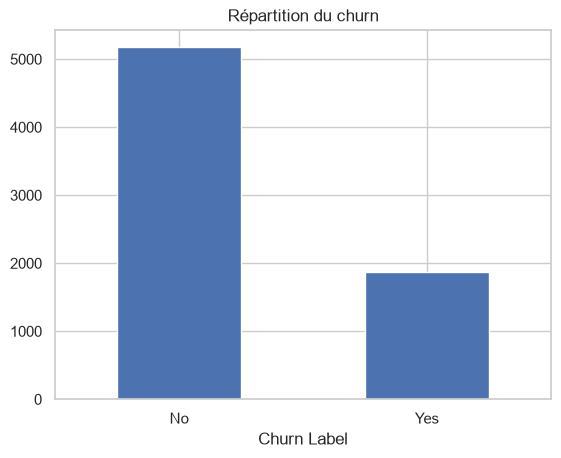

In [10]:
TARGET = "Churn Value"  # 0 = reste, 1 = parti ; la moyenne de cette colonne est le taux de churn

print(df["Churn Label"].value_counts())
print(df["Churn Label"].value_counts(normalize=True).round(3))

df["Churn Label"].value_counts().plot(kind="bar", title="Répartition du churn")
plt.xticks(rotation=0)
plt.show()

- **Observation** : 5 174 clients restés et 1 869 partis, soit 26,5 % de churn.
- **Conclusion** : les classes sont déséquilibrées. Un modèle qui répondrait toujours « reste » aurait 73,5 % d'accuracy sans rien apprendre.
- **Décision** : découpage et validation croisée stratifiés ; évaluer avec le recall, la precision et la PR-AUC plutôt qu'avec l'accuracy.

## 4. Variables numériques

### 4.1 Distributions selon le churn
- **Pourquoi** : comparer la forme des variables numériques entre clients partis et restés.
- **Attente** : les clients partis ont une ancienneté plus courte.

            Tenure Months        Monthly Charges        Total Charges        
                     mean median            mean median          mean  median
Churn Label                                                                  
No                   37.6   38.0            61.3   64.4        2549.9  1679.5
Yes                  18.0   10.0            74.4   79.6        1531.8   703.6


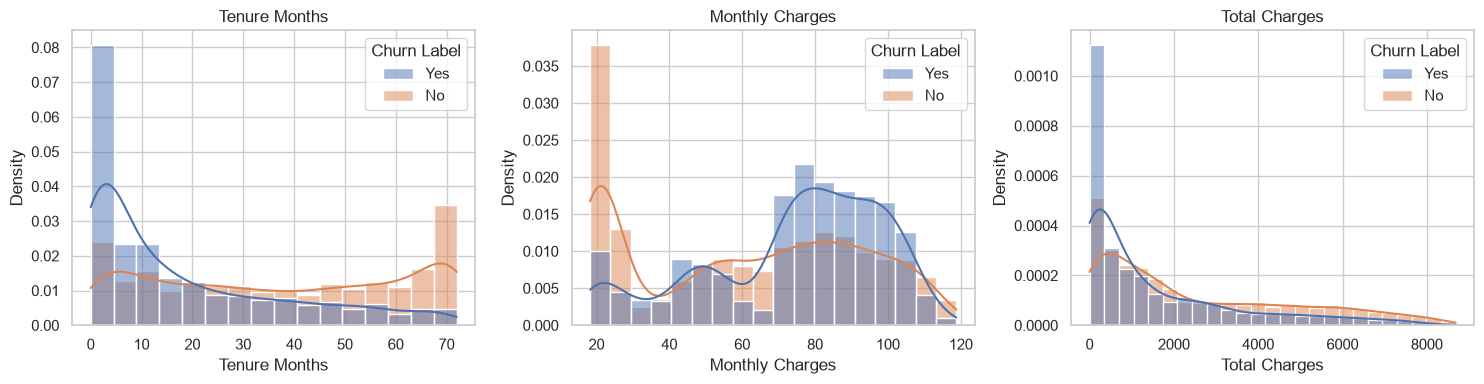

In [11]:
num_cols = ["Tenure Months", "Monthly Charges", "Total Charges"]
print(df.groupby("Churn Label")[num_cols].agg(["mean", "median"]).round(1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, num_cols):
    sns.histplot(data=df, x=c, hue="Churn Label", ax=ax, kde=True,
                 stat="density", common_norm=False)
    ax.set_title(c)
plt.tight_layout()
plt.savefig("../images/distributions_numeriques.png", dpi=150, bbox_inches="tight")
plt.show()

- **Observation** : l'ancienneté médiane est de 10 mois chez les partis contre 38 chez les restés. Les frais mensuels médians sont de 79,6 contre 64,4, et le total facturé médian de 704 contre 1 680.
- **Conclusion** : le départ se joue surtout dans les premiers mois. Les partis paient plus cher en médiane, mais on verra en 6.1 que cela vient du type d'internet. `Total Charges` reflète surtout l'ancienneté. Chez les partis, la moyenne d'ancienneté (18) est loin de la médiane (10) : la médiane représente mieux le groupe.
- **Décision** : garder `Tenure Months` et `Monthly Charges`, et regarder la redondance de `Total Charges` en 4.3.

### 4.2 Churn par tranche d'ancienneté
- **Pourquoi** : voir à partir de quand le risque baisse.
- **Attente** : le churn diminue quand l'ancienneté augmente.

               mean  count
tenure_group              
0-12          0.474   2186
13-24         0.287   1024
25-48         0.204   1594
49-72         0.095   2239


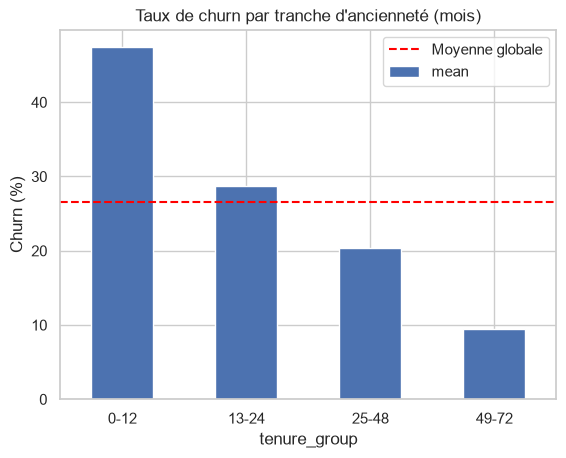

In [12]:
df["tenure_group"] = pd.cut(df["Tenure Months"], bins=[-1, 12, 24, 48, 72],
                            labels=["0-12", "13-24", "25-48", "49-72"])

tenure_rates = (df.groupby("tenure_group", observed=True)[TARGET]
                  .agg(["mean", "count"]).round(3))
print(tenure_rates)

ax = (tenure_rates["mean"] * 100).plot(
    kind="bar", title="Taux de churn par tranche d'ancienneté (mois)")
ax.axhline(df[TARGET].mean() * 100, color="red", ls="--", label="Moyenne globale")
ax.set_ylabel("Churn (%)")
ax.legend()
plt.xticks(rotation=0)
plt.savefig("../images/churn_par_anciennete.png", dpi=150, bbox_inches="tight")
plt.show()

- **Observation** : le churn est de 47,4 % entre 0 et 12 mois, 28,7 % entre 13 et 24, 20,4 % entre 25 et 48, et 9,5 % après 48 mois. Chaque tranche compte entre 1 024 et 2 239 clients.
- **Conclusion** : le risque baisse à chaque tranche et se concentre sur la première année.
- **Décision** : `tenure_group` ne sert qu'à l'analyse. Le modèle utilisera `Tenure Months` directement.

### 4.3 Corrélations
- **Pourquoi** : mesurer les liens linéaires entre les variables numériques, et avec le churn.
- **Attente** : `Total Charges` est fortement corrélée à `Tenure Months`.

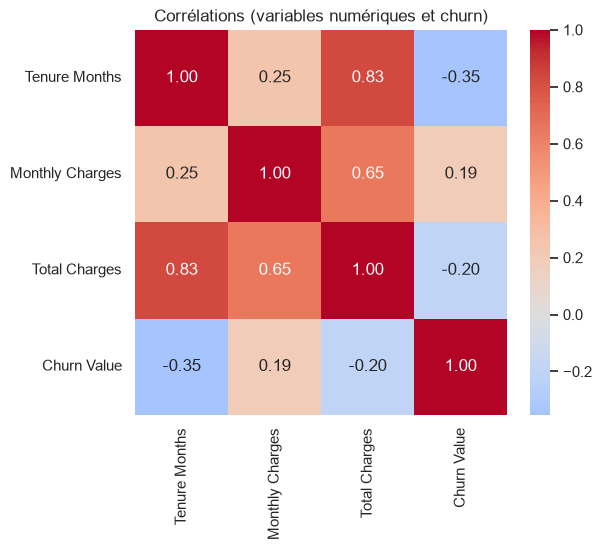

In [13]:
corr = df[num_cols + [TARGET]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Corrélations (variables numériques et churn)")
plt.savefig("../images/correlations.png", dpi=150, bbox_inches="tight")
plt.show()

- **Observation** : `Tenure Months` et `Total Charges` sont corrélées à 0,83, `Monthly Charges` et `Total Charges` à 0,65. Avec le churn : −0,35 pour `Tenure Months`, −0,20 pour `Total Charges` et +0,19 pour `Monthly Charges`.
- **Conclusion** : `Total Charges` est à peu près l'ancienneté multipliée par les frais mensuels. Elle est redondante, et moins liée au churn que l'ancienneté. Ces corrélations sont linéaires, et le +0,19 de `Monthly Charges` est trompeur (voir 6.1).
- **Décision** : pour la régression logistique, tester avec et sans `Total Charges`. Les arbres (Random Forest, XGBoost) supportent bien cette redondance.

## 5. Variables catégorielles

### 5.1 Variables principales
- **Pourquoi** : comparer le taux de churn de chaque groupe à la moyenne globale (26,5 %), en regardant toujours l'effectif.

In [14]:
def churn_table(col):
    """Taux de churn et effectif par modalité de `col`, trié par taux décroissant."""
    t = df.groupby(col)[TARGET].agg(["mean", "count"]).round(3)
    t.columns = ["taux_churn", "effectif"]
    return t.sort_values("taux_churn", ascending=False)


cat_cols = ["Contract", "Payment Method", "Internet Service", "Senior Citizen",
            "Paperless Billing", "Tech Support", "Online Security"]

for c in cat_cols:
    print(f"\n{c}\n{churn_table(c)}")


Contract
                taux_churn  effectif
Contract                            
Month-to-month       0.427      3875
One year             0.113      1473
Two year             0.028      1695

Payment Method
                           taux_churn  effectif
Payment Method                                 
Electronic check                0.453      2365
Mailed check                    0.191      1612
Bank transfer (automatic)       0.167      1544
Credit card (automatic)         0.152      1522

Internet Service
                  taux_churn  effectif
Internet Service                      
Fiber optic            0.419      3096
DSL                    0.190      2421
No                     0.074      1526

Senior Citizen
                taux_churn  effectif
Senior Citizen                      
Yes                  0.417      1142
No                   0.236      5901

Paperless Billing
                   taux_churn  effectif
Paperless Billing                      
Yes                     0

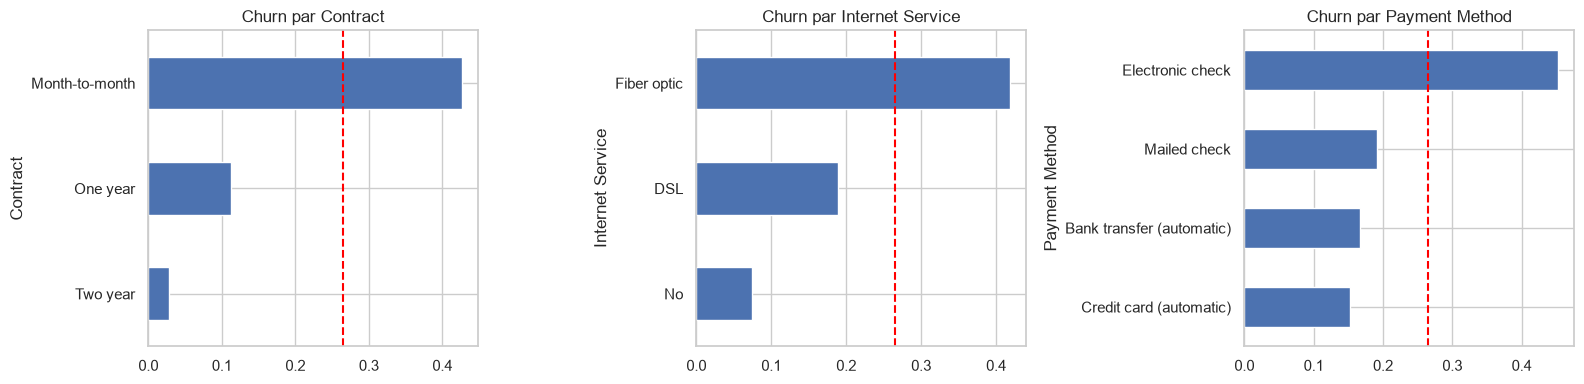

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, ["Contract", "Internet Service", "Payment Method"]):
    df.groupby(c)[TARGET].mean().sort_values().plot(kind="barh", ax=ax, title=f"Churn par {c}")
    ax.axvline(df[TARGET].mean(), color="red", ls="--")  # moyenne globale
plt.tight_layout()
plt.savefig("../images/churn_par_contrat.png", dpi=150, bbox_inches="tight")
plt.show()

- **Observation** :
  - Contrat : 42,7 % de churn en mensuel contre 2,8 % sur 2 ans.
  - Paiement : 45,3 % par chèque électronique, contre 15 à 19 % pour les autres modes.
  - Internet : 41,9 % en fibre, 19,0 % en DSL et 7,4 % sans internet.
  - Options : environ 42 % sans support technique ou sans sécurité en ligne, contre environ 15 % avec.
  - Seniors : 41,7 % contre 23,6 %.
  - Tous les groupes ont plus de 1 100 clients.
- **Conclusion** : le contrat est le signal le plus fort : le taux est multiplié par environ 15 entre le mensuel et le 2 ans. Ces variables se recoupent : « No internet service » désigne le même groupe de 1 526 clients dans plusieurs colonnes. On ne peut pas parler de cause.
- **Décision** : garder ces variables, croiser contrat et type d'internet (6.2), et vérifier le support technique et la sécurité en ligne à contrat fixé (5.4).

### 5.2 Autres variables de profil et de services
- **Pourquoi** : avant de retirer une variable, je regarde ce qu'elle apporte.
- **Attente** :
  - `Gender` : pas de différence.
  - `Partner`, `Dependents` : taux plus bas chez ceux qui en ont.
  - `Online Backup`, `Device Protection` : taux plus bas chez ceux qui y ont souscrit.
  - `Streaming TV`, `Streaming Movies`, `Multiple Lines`, `Phone Service` : pas d'idée précise.

In [16]:
other_cols = ["Gender", "Partner", "Dependents", "Phone Service", "Multiple Lines",
              "Online Backup", "Device Protection", "Streaming TV", "Streaming Movies"]

for c in other_cols:
    print(f"\n{c}\n{churn_table(c)}")


Gender
        taux_churn  effectif
Gender                      
Female       0.269      3488
Male         0.262      3555

Partner
         taux_churn  effectif
Partner                      
No            0.330      3641
Yes           0.197      3402

Dependents
            taux_churn  effectif
Dependents                      
No               0.326      5416
Yes              0.065      1627

Phone Service
               taux_churn  effectif
Phone Service                      
Yes                 0.267      6361
No                  0.249       682

Multiple Lines
                  taux_churn  effectif
Multiple Lines                        
Yes                    0.286      2971
No                     0.250      3390
No phone service       0.249       682

Online Backup
                     taux_churn  effectif
Online Backup                            
No                        0.399      3088
Yes                       0.215      2429
No internet service       0.074      1526

Device 

- **Observation** :
  - `Gender` : 26,9 % contre 26,2 %.
  - `Partner` : 33,0 % sans partenaire contre 19,7 % avec. `Dependents` : 32,6 % sans personne à charge contre 6,5 % avec.
  - `Online Backup` : 39,9 % sans contre 21,5 % avec. `Device Protection` : 39,1 % contre 22,5 %.
  - Écarts faibles : `Phone Service` 1,8 point (le groupe sans téléphone n'a que 682 clients), `Multiple Lines` 3,6, `Streaming TV` 3,4, `Streaming Movies` 3,8.
  - Dans les six colonnes d'options internet, la modalité « No internet service » est le même groupe de 1 526 clients (7,4 % de churn).
- **Conclusion** : `Gender` n'a aucun lien avec le churn. `Partner`, `Dependents`, `Online Backup` et `Device Protection` en ont un lien net. Les options de streaming, `Multiple Lines` et `Phone Service` ont des écarts faibles, proches de l'incertitude statistique. Deux doutes restent : `Partner` et `Dependents` se recoupent peut-être, et l'écart d'`Online Backup` peut venir du contrat (voir 5.3).
- **Décision** : retirer `Gender` (aucun signal, et question d'équité). Garder les autres pour l'instant, et tester par validation croisée le retrait de `Phone Service`, `Multiple Lines`, `Streaming TV` et `Streaming Movies`.

### 5.3 Vérification des recoupements
- **Pourquoi** : lever deux doutes de 5.2.
  1. `Partner` et `Dependents` ont chacune un écart net avec le churn. Se recoupent-elles ? Si oui, les garder toutes les deux apporte peu.
  2. Les clients avec `Online Backup` sont peut-être surtout en contrat long, qui churne peu. Les 18 points d'écart viennent-ils de la sauvegarde ou du contrat ?
- **Attente** :
  - `Partner` et `Dependents` : je pense qu'elles se recoupent (un client en couple a plus souvent des personnes à charge), mais sans dire exactement la même chose.
  - `Online Backup` : je pense que les clients sans sauvegarde sont surtout en contrat mensuel, donc que l'écart diminue à contrat fixé.

In [17]:
# Part des clients avec / sans personnes à charge, selon la situation de couple
print(pd.crosstab(df["Partner"], df["Dependents"], normalize="index").round(2))

Dependents    No   Yes
Partner               
No          0.92  0.08
Yes         0.61  0.39


In [18]:
# Online Backup à contrat fixé, sur les clients qui ont internet uniquement
inet = df[df["Internet Service"] != "No"]
print(inet.pivot_table(index="Contract", columns="Online Backup",
                       values=TARGET, aggfunc=["mean", "count"]).round(3))

                 mean        count      
Online Backup      No    Yes    No   Yes
Contract                                
Month-to-month  0.503  0.381  2288  1063
One year        0.133  0.148   487   622
Two year        0.054  0.035   313   744


- **Observation** :
  - Parmi les clients sans partenaire, 8 % ont des personnes à charge, contre 39 % parmi ceux qui ont un partenaire.
  - À contrat fixé, pour `Online Backup` : en mensuel 50,3 % sans contre 38,1 % avec (12 points d'écart), en 1 an 13,3 % contre 14,8 %, en 2 ans 5,4 % contre 3,5 %. Chaque case compte entre 313 et 2 288 clients.
  - 74 % des clients sans sauvegarde sont en contrat mensuel, contre 44 % de ceux qui en ont une.
- **Conclusion** :
  - `Partner` et `Dependents` sont liées, mais pas redondantes : 61 % des clients avec partenaire n'ont personne à charge. Chacune garde sa propre information.
  - Les 18 points d'écart d'`Online Backup` viennent en grande partie du contrat. À contrat fixé, l'écart tombe à 12 points en mensuel et devient très faible en 1 an et en 2 ans. C'est un effet de confusion, comme pour le prix.
- **Décision** : garder `Partner` et `Dependents`. Garder `Online Backup` pour l'instant, en sachant que son apport propre est limité, et tester son retrait par validation croisée. Faire le même contrôle pour les trois autres options (5.4).

### 5.4 Contrôle par le contrat des autres options
- **Pourquoi** : l'écart d'`Online Backup` a presque disparu à contrat fixé. Je vérifie si c'est pareil pour `Tech Support`, `Online Security` et `Device Protection`, que je citais comme facteurs de risque en 5.1 et 5.2.
- **Attente** : d'après 5.3, je m'attends à ce que l'écart diminue aussi pour ces trois options, parce que les clients sans option sont probablement surtout en contrat mensuel.

In [19]:
inet = df[df["Internet Service"] != "No"]

for c in ["Tech Support", "Online Security", "Device Protection"]:
    print(f"\n{c}")
    print(inet.pivot_table(index="Contract", columns=c,
                           values=TARGET, aggfunc=["mean", "count"]).round(3))


Tech Support
                 mean        count     
Tech Support       No    Yes    No  Yes
Contract                               
Month-to-month  0.504  0.307  2680  671
One year        0.147  0.136   557  552
Two year        0.059  0.035   236  821

Online Security
                  mean        count     
Online Security     No    Yes    No  Yes
Contract                                
Month-to-month   0.510  0.296  2631  720
One year         0.174  0.109   557  552
Two year         0.068  0.029   310  747

Device Protection
                    mean        count     
Device Protection     No    Yes    No  Yes
Contract                                  
Month-to-month     0.476  0.436  2394  957
One year           0.136  0.146   463  646
Two year           0.038  0.042   238  819


- **Observation** :
  - En contrat mensuel, l'écart reste net pour `Tech Support` (50,4 % sans contre 30,7 % avec) et `Online Security` (51,0 % contre 29,6 %), mais devient faible pour `Device Protection` (47,6 % contre 43,6 %).
  - En contrat d'un an et de 2 ans, les écarts sont petits : `Online Security` garde 6,5 et 3,9 points, `Tech Support` 1,1 et 2,4, et `Device Protection` est légèrement inversé.
  - Les clients sans option sont surtout en contrat mensuel : 77 % sans `Tech Support` contre 33 % avec, 75 % sans `Online Security` contre 36 % avec, 77 % sans `Device Protection` contre 40 % avec.
  - Chaque case compte entre 236 et 2 680 clients, mais en contrat de 2 ans il n'y a que 10 à 35 départs environ par case.
- **Conclusion** :
  - `Device Protection` : ses 17 points d'écart globaux viennent presque entièrement du contrat. À contrat fixé, il ne reste rien de net.
  - `Tech Support` et `Online Security` : une partie de l'écart vient du contrat, mais environ 20 points subsistent en contrat mensuel. `Online Security` garde en plus un écart modeste dans les autres contrats.
  - En contrat mensuel, l'écart restant se classe ainsi : `Online Security` (21 points), `Tech Support` (20), `Online Backup` (12), `Device Protection` (4).
  - Je n'ai contrôlé que le contrat : le type d'internet ou l'ancienneté peuvent encore jouer. Ce sont des associations, pas des causes.
- **Décision** : garder `Tech Support` et `Online Security`. Garder `Online Backup` et `Device Protection` pour l'instant, et tester leur retrait par validation croisée.

## 6. Croisements

### 6.1 Prix et type d'internet
- **Pourquoi** : les partis paient plus cher en global. Est-ce l'effet du prix ou du type d'internet ?
- **Attente** : les clients partis paient plus cher, même à type d'internet égal.

In [20]:
print(df.groupby("Internet Service")["Monthly Charges"].median())
print()
print(df.groupby(["Internet Service", "Churn Label"])["Monthly Charges"]
        .median().unstack().round(1))

Internet Service
DSL            56.150
Fiber optic    91.675
No             20.150
Name: Monthly Charges, dtype: float64

Churn Label         No   Yes
Internet Service            
DSL               59.8  49.2
Fiber optic       94.8  87.6
No                20.2  20.0


- **Observation** : les frais mensuels médians sont de 20,2 sans internet, 56,2 en DSL et 91,7 en fibre. À type d'internet égal, les partis paient moins que les restés : DSL 49,2 contre 59,8, fibre 87,6 contre 94,8, sans internet 20,0 contre 20,2.
- **Conclusion** : l'écart de prix du départ vient du type d'internet : les partis sont surtout en fibre, la formule la plus chère. C'est un paradoxe de Simpson. Le pic de factures autour de 20 correspond aux clients sans internet. Ce sont des médianes, sans test statistique : on ne peut pas dire que le prix n'a aucun effet, seulement qu'il n'explique pas à lui seul le churn.
- **Décision** : ne pas écrire que le prix fait partir les clients, et garder `Monthly Charges` et `Internet Service` dans le modèle.

### 6.2 Contrat × type d'internet
- **Pourquoi** : la fibre est-elle plus risquée à contrat fixé, ou est-ce un effet du contrat ?
- **Attente** : à contrat fixé, je m'attends à ce que la fibre soit plus risquée que le DSL. Je m'attends à ce que l'écart soit plus petit en contrat de 2 ans, car l'ancienneté réduit l'écart. Les clients sans internet devraient avoir un taux bas dans tous les contrats.

In [21]:
pivot = pd.pivot_table(df, index="Contract", columns="Internet Service",
                       values=TARGET, aggfunc=["mean", "count"]).round(3)
pivot

mean                    count                 
Internet Service    DSL Fiber optic     No   DSL Fiber optic   No
Contract                                                         
Month-to-month    0.322       0.546  0.189  1223        2128  524
One year          0.093       0.193  0.025   570         539  364
Two year          0.019       0.072  0.008   628         429  638

- **Observation** : à contrat fixé, la fibre churne plus que le DSL dans les trois contrats : 54,6 % contre 32,2 % en mensuel, 19,3 % contre 9,3 % en 1 an, 7,2 % contre 1,9 % en 2 ans. Sans internet, les taux sont les plus bas : 18,9 %, 2,5 % et 0,8 %. Toutes les cases ont plus de 360 clients, mais en contrat de 2 ans il n'y a que 5 à 31 départs environ par case.
- **Conclusion** : la fibre reste plus risquée à contrat fixé, donc son churn élevé ne vient pas seulement d'une présence plus forte en contrat mensuel. L'écart en points diminue avec la durée du contrat (22, 10 puis 5), mais le rapport fibre / DSL augmente (1,7, 2,1 puis 3,8) : la baisse de l'écart en points vient en partie du fait que les taux sont déjà très bas en contrat de 2 ans. Ces taux sont imprécis. Le tableau ne dit pas pourquoi la fibre churne plus : le prix n'est qu'une hypothèse, que 6.1 n'a pas confirmée.
- **Décision** : garder `Contract` et `Internet Service`, et tester une interaction contrat × internet pour la régression logistique. Dans le README, écrire que la fibre est associée à un churn plus élevé, sans parler de cause.

## 7. Colonnes exclues et variables retenues
- **Fuites de données** : colonnes connues seulement après le départ, ou construites à partir de la cible (`Churn Score` et `CLTV` sont exclues par prudence).
- **Sans valeur prédictive** : identifiants, constantes, colonnes géographiques.
- **Sans signal** : `Gender` (26,9 % contre 26,2 % de churn).

In [22]:
leakage = ["Churn Label", "Churn Value", "Churn Score", "CLTV", "Churn Reason"]
useless = ["CustomerID", "Count", "Country", "State", "City",
           "Zip Code", "Lat Long", "Latitude", "Longitude"]
no_signal = ["Gender"]  # 26,9 % contre 26,2 % de churn

features = [c for c in df.columns
            if c not in leakage + useless + no_signal + ["tenure_group"]]
print(len(features), "variables retenues")
print(features)

18 variables retenues
['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges']


- **Observation** : 18 variables retenues sur 33 colonnes : 3 numériques et 15 catégorielles.
- **Conclusion** : la liste garde `Total Charges`, redondante avec l'ancienneté. Elle garde aussi des variables à l'apport limité : `Online Backup` et `Device Protection` (5.3 et 5.4), ainsi que `Streaming TV`, `Streaming Movies`, `Multiple Lines` et `Phone Service` (5.2).
- **Décision** : c'est le point de départ de la modélisation. Comparer par validation croisée les versions avec et sans ces variables, et avec et sans `Total Charges` pour la régression logistique.

## 8. Synthèse

- **Données** : 7 043 clients, aucun doublon. Les 11 valeurs manquantes de `Total Charges` sont des clients à 0 mois d'ancienneté, remplacées par 0.
- **Cible** : 26,5 % de churn, classes déséquilibrées. Découpage stratifié, évaluation par recall, precision et PR-AUC.
- **Ancienneté** : 47,4 % de churn la première année contre 9,5 % après 4 ans.
- **Contrat** : 42,7 % en mensuel contre 2,8 % sur 2 ans, c'est le signal le plus fort.
- **Fibre** : plus risquée que le DSL dans chacun des trois contrats (54,6 % contre 32,2 % en mensuel).
- **Prix** : l'écart global vient du type d'internet (paradoxe de Simpson). Le prix seul n'explique pas le churn.
- **Options de service** : leurs écarts viennent en grande partie du contrat. À contrat fixé, `Device Protection` n'a presque plus d'écart, alors que `Tech Support` et `Online Security` gardent environ 20 points en contrat mensuel.
- **Profil** : le churn est plus bas chez les clients avec partenaire ou personnes à charge. `Gender` est retirée, faute de signal.
- **Autres profils à risque** (pas contrôlés par le contrat) : chèque électronique (45,3 %) et seniors (41,7 %).
- **Exclusions** : `Churn Reason`, `Churn Score` et `CLTV` (fuite), plus les identifiants et la géographie.
- **Redondance** : `Total Charges` est corrélée à 0,83 avec `Tenure Months`.
- **Limites** : associations et non causes, médianes sans test statistique, données fictives sans dimension temporelle.

**Prochaine étape** : `02_modeling.ipynb` : découpage train/test stratifié, encodage ajusté sur le train, baseline de régression logistique, puis Random Forest et XGBoost.